# Notebook 4: Strategy Comparison & Visualisation
**Purpose:** Load all backtest results, compute metrics, and generate all comparison charts.  
**Prerequisites:** Run notebooks 1, 2, and 3 first.  
**GPU:** Not needed.

In [1]:
import os
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from config import (
    ALL_TICKERS, US_STOCKS, INDIAN_STOCKS, CRYPTO, GOLD,
    RESULTS_DIR, PLOTS_DIR,
)
from utils import setup_logging, create_directories, compute_metrics, get_asset_class

logger = setup_logging('comparison')
create_directories()
os.makedirs(os.path.join(PLOTS_DIR, 'equity_curves'), exist_ok=True)
os.makedirs(os.path.join(PLOTS_DIR, 'comparison'), exist_ok=True)
os.makedirs(os.path.join(PLOTS_DIR, 'heatmaps'), exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')

# consistent colours and display labels across all plots
STRATEGY_COLORS = {
    'technical':   '#2196F3',
    'ml_lgbm':     '#FF9800',
    'ml_logreg':   '#4CAF50',
    'dl_lstm':     '#F44336',
    'buy_and_hold':'#9E9E9E',
}
STRATEGY_LABELS = {
    'technical':   'Technical',
    'ml_lgbm':     'LightGBM',
    'ml_logreg':   'LogReg',
    'dl_lstm':     'LSTM',
    'buy_and_hold':'Buy & Hold',
}

print('Setup complete.')

Setup complete.


## 1. Load All Results

In [2]:
def load_portfolio(strategy_name):
    """
    Load the combined portfolio history parquet for a strategy.
    Returns a DataFrame with columns [ticker, portfolio_value, daily_return, ...].
    Returns None if the file doesn't exist (strategy wasn't run).
    """
    path = os.path.join(RESULTS_DIR, f'{strategy_name}_results.parquet')
    if not os.path.exists(path):
        print(f'  WARNING: {path} not found — skipping {strategy_name}.')
        return None
    return pd.read_parquet(path)


def load_orderbook(strategy_name):
    """Load the order book for a strategy. Returns empty DataFrame if missing."""
    path = os.path.join(RESULTS_DIR, f'{strategy_name}_orderbook.parquet')
    if not os.path.exists(path):
        return pd.DataFrame()
    return pd.read_parquet(path)


# load everything
STRATEGIES = ['technical', 'ml_lgbm', 'ml_logreg', 'dl_lstm', 'buy_and_hold']

portfolios  = {}   # strategy -> combined DataFrame (all assets)
orderbooks  = {}   # strategy -> combined order book

for name in STRATEGIES:
    ph = load_portfolio(name)
    if ph is not None:
        portfolios[name] = ph
        print(f'  Loaded {name}: {len(ph)} rows, {ph["ticker"].nunique()} assets')
    orderbooks[name] = load_orderbook(name)

print(f'\nLoaded {len(portfolios)} strategies.')

  Loaded technical: 19520 rows, 20 assets
  Loaded ml_lgbm: 19520 rows, 20 assets
  Loaded ml_logreg: 19520 rows, 20 assets
  Loaded dl_lstm: 19520 rows, 20 assets
  Loaded buy_and_hold: 19520 rows, 20 assets

Loaded 5 strategies.


## 2. Compute Metrics

In [3]:
def get_per_asset_metrics(strategy_name, combined_ph):
    """
    Split a combined portfolio history by ticker and compute metrics per asset.
    Returns dict: {ticker -> metrics_dict}
    """
    result = {}
    for ticker in ALL_TICKERS:
        subset = combined_ph[combined_ph['ticker'] == ticker].copy()
        if len(subset) == 0:
            continue
        # compute_metrics expects daily_return column
        m = compute_metrics(subset)
        result[ticker] = m
    return result


# compute per-asset metrics for every strategy
all_metrics = {}   # strategy -> {ticker -> metrics}
for name, ph in portfolios.items():
    all_metrics[name] = get_per_asset_metrics(name, ph)
    n = len(all_metrics[name])
    print(f'{name}: metrics for {n} assets')

technical: metrics for 20 assets
ml_lgbm: metrics for 20 assets
ml_logreg: metrics for 20 assets
dl_lstm: metrics for 20 assets
buy_and_hold: metrics for 20 assets


## 3. Master Comparison Table

In [4]:
def build_comparison_table(all_metrics):
    """
    Build a flat DataFrame: one row per (strategy, ticker) with all metrics.
    Useful for filtering and aggregation downstream.
    """
    rows = []
    for strategy, ticker_metrics in all_metrics.items():
        for ticker, m in ticker_metrics.items():
            rows.append({
                'strategy':     strategy,
                'ticker':       ticker,
                'asset_class':  get_asset_class(ticker),
                'total_return': m.get('total_return', np.nan),
                'sharpe_ratio': m.get('sharpe_ratio', np.nan),
                'max_drawdown': m.get('max_drawdown', np.nan),
                'num_trades':   m.get('num_trades', 0),
            })
    return pd.DataFrame(rows)


comparison_df = build_comparison_table(all_metrics)

# print a readable pivot: strategies as columns, tickers as rows, showing return %
pivot = comparison_df.pivot_table(
    index='ticker', columns='strategy', values='total_return'
) * 100

# reorder columns to a sensible display order
col_order = [c for c in ['buy_and_hold','technical','ml_logreg','ml_lgbm','dl_lstm'] if c in pivot.columns]
pivot = pivot[col_order].round(1)
pivot.columns = [STRATEGY_LABELS.get(c, c) for c in pivot.columns]

print('Total Return % by Ticker and Strategy')
print('=' * 70)
print(pivot.to_string())
print('\nAverages:')
print(pivot.mean().to_string())

Total Return % by Ticker and Strategy
               Buy & Hold  Technical  LogReg  LightGBM  LSTM
ticker                                                      
AAPL                 61.7       17.7    20.9       1.0  21.6
AMZN                 77.6       20.3    -3.2       4.8  14.8
BHARTIARTL.NS        95.4       44.8    26.8      19.4  46.7
BTC-USD               0.0        0.0     0.0       0.0   0.0
ETH-USD              12.5       -3.4    13.7       3.4  24.3
GC=F                 27.9       -0.3     7.2      15.0   8.8
GOOGL                67.9       16.3     2.3     -10.9  10.5
HDFCBANK.NS          19.4      -11.0     6.0      16.2   6.8
ICICIBANK.NS         59.8       12.5     9.8      -5.1  15.6
INFY.NS              18.0       13.9    -1.7     -35.0  18.1
JNJ                 -13.8      -12.2     6.8      -0.9  -6.1
JPM                 114.3       23.8    16.6      28.1  17.9
META                195.0       46.7    38.3      39.8  27.9
MSFT                 54.8       11.0     2.7   

## 4. Equity Curves (per asset)

Saved: plots/equity_curves/all_assets_equity_curves.png


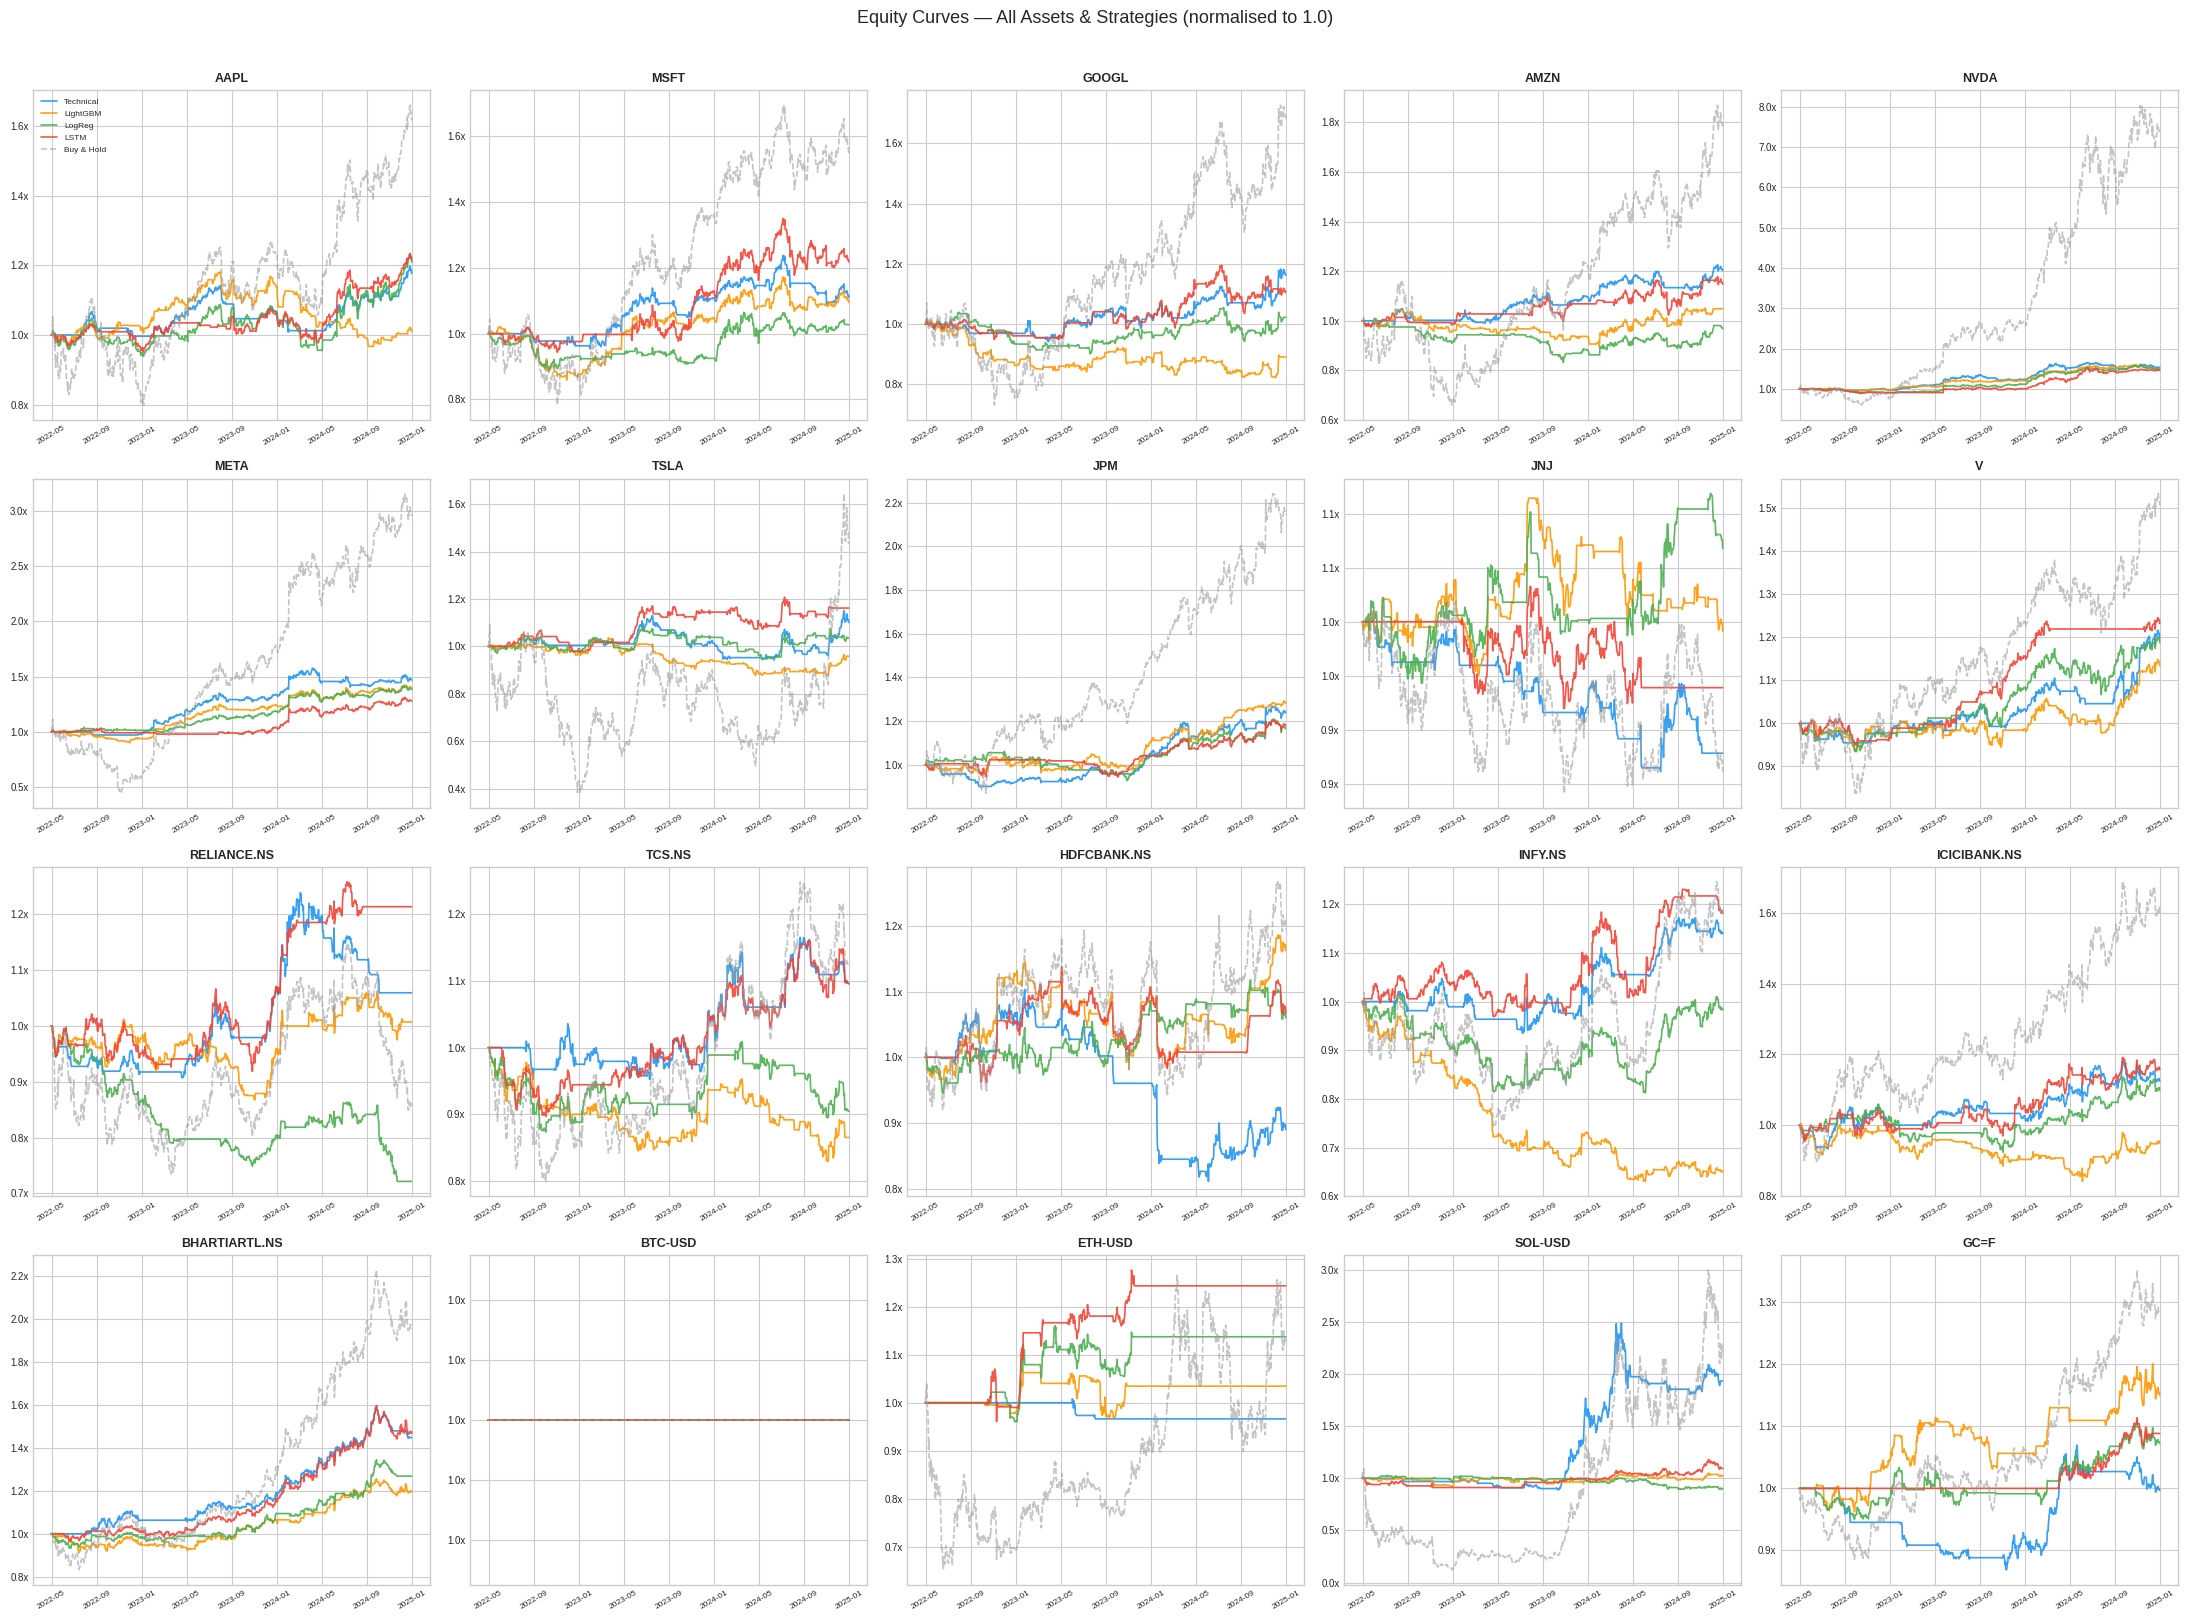

In [5]:
def plot_equity_curves(portfolios, all_tickers, save_dir):
    """
    Small-multiples grid — one subplot per asset.
    Each subplot shows normalised portfolio value (start = 1.0) for all strategies.
    Saves one combined figure to save_dir.
    """
    n_cols = 5
    n_rows = 4   # 20 assets total
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 16), sharex=False)
    axes = axes.flatten()

    for ax_idx, ticker in enumerate(all_tickers):
        ax = axes[ax_idx]

        for strategy, ph in portfolios.items():
            subset = ph[ph['ticker'] == ticker]['portfolio_value']
            if len(subset) == 0:
                continue
            # normalise to 1.0 at start so different capital scales don't matter
            normalised = subset / subset.iloc[0]
            linestyle = '--' if strategy == 'buy_and_hold' else '-'
            alpha     = 0.6  if strategy == 'buy_and_hold' else 0.9
            ax.plot(
                subset.index, normalised,
                label=STRATEGY_LABELS.get(strategy, strategy),
                color=STRATEGY_COLORS.get(strategy, 'black'),
                linewidth=1.2,
                linestyle=linestyle,
                alpha=alpha,
            )

        ax.set_title(ticker, fontsize=9, fontweight='bold')
        ax.set_xlabel('')
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1fx'))
        ax.tick_params(axis='x', labelsize=6, rotation=30)
        ax.tick_params(axis='y', labelsize=7)
        # only add legend to the first subplot to avoid clutter
        if ax_idx == 0:
            ax.legend(fontsize=6, loc='upper left')

    # hide any unused axes (if < 20 tickers somehow)
    for i in range(len(all_tickers), len(axes)):
        axes[i].set_visible(False)

    fig.suptitle('Equity Curves — All Assets & Strategies (normalised to 1.0)', fontsize=13, y=1.01)
    plt.tight_layout()
    path = os.path.join(save_dir, 'equity_curves', 'all_assets_equity_curves.png')
    plt.savefig(path, bbox_inches='tight', dpi=150)
    print(f'Saved: {path}')
    plt.show()


plot_equity_curves(portfolios, ALL_TICKERS, PLOTS_DIR)

## 5. Strategy Comparison Bar Charts

Saved: plots/comparison/strategy_comparison_bars.png


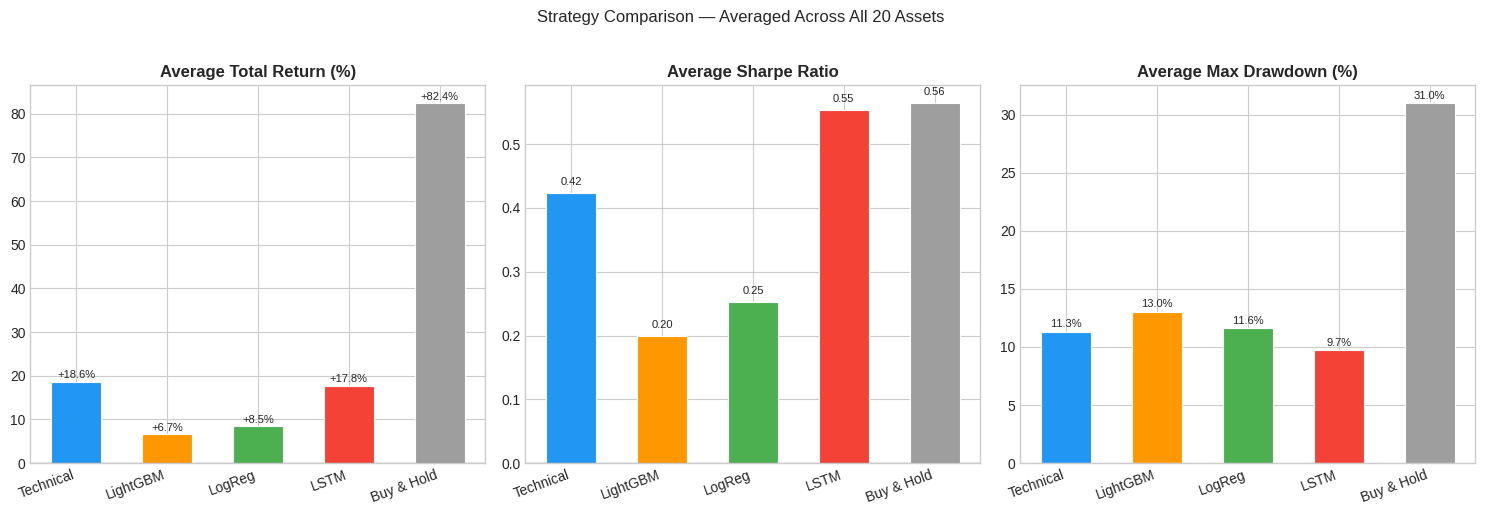

In [6]:
def plot_strategy_comparison(comparison_df, save_dir):
    """
    Three side-by-side bar charts: avg return, avg Sharpe, avg max drawdown.
    One bar per strategy, averaged across all assets.
    """
    strategies = [s for s in STRATEGIES if s in comparison_df['strategy'].unique()]
    labels     = [STRATEGY_LABELS.get(s, s) for s in strategies]
    colors     = [STRATEGY_COLORS.get(s, 'gray') for s in strategies]

    avg = comparison_df.groupby('strategy').agg(
        avg_return  = ('total_return',  'mean'),
        avg_sharpe  = ('sharpe_ratio',  'mean'),
        avg_maxdd   = ('max_drawdown',  'mean'),
    ).reindex(strategies)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    x = np.arange(len(strategies))
    bar_w = 0.55

    # total return
    bars = axes[0].bar(x, avg['avg_return'] * 100, width=bar_w, color=colors, edgecolor='white', linewidth=0.8)
    axes[0].set_title('Average Total Return (%)', fontweight='bold')
    axes[0].set_xticks(x); axes[0].set_xticklabels(labels, rotation=20, ha='right')
    axes[0].axhline(0, color='black', linewidth=0.8)
    for bar in bars:
        h = bar.get_height()
        axes[0].text(bar.get_x() + bar_w/2, h + (0.3 if h >= 0 else -1.5),
                     f'{h:+.1f}%', ha='center', va='bottom', fontsize=8)

    # sharpe ratio
    bars = axes[1].bar(x, avg['avg_sharpe'], width=bar_w, color=colors, edgecolor='white', linewidth=0.8)
    axes[1].set_title('Average Sharpe Ratio', fontweight='bold')
    axes[1].set_xticks(x); axes[1].set_xticklabels(labels, rotation=20, ha='right')
    axes[1].axhline(0, color='black', linewidth=0.8)
    for bar in bars:
        h = bar.get_height()
        axes[1].text(bar.get_x() + bar_w/2, h + 0.01, f'{h:.2f}', ha='center', va='bottom', fontsize=8)

    # max drawdown (shown as positive % for readability)
    bars = axes[2].bar(x, avg['avg_maxdd'] * 100, width=bar_w, color=colors, edgecolor='white', linewidth=0.8)
    axes[2].set_title('Average Max Drawdown (%)', fontweight='bold')
    axes[2].set_xticks(x); axes[2].set_xticklabels(labels, rotation=20, ha='right')
    for bar in bars:
        h = bar.get_height()
        axes[2].text(bar.get_x() + bar_w/2, h + 0.2, f'{h:.1f}%', ha='center', va='bottom', fontsize=8)

    plt.suptitle('Strategy Comparison — Averaged Across All 20 Assets', fontsize=12, y=1.02)
    plt.tight_layout()
    path = os.path.join(save_dir, 'comparison', 'strategy_comparison_bars.png')
    plt.savefig(path, bbox_inches='tight', dpi=150)
    print(f'Saved: {path}')
    plt.show()


plot_strategy_comparison(comparison_df, PLOTS_DIR)

## 6. Return Heatmap (Strategy × Asset)

Saved: plots/heatmaps/return_heatmap.png


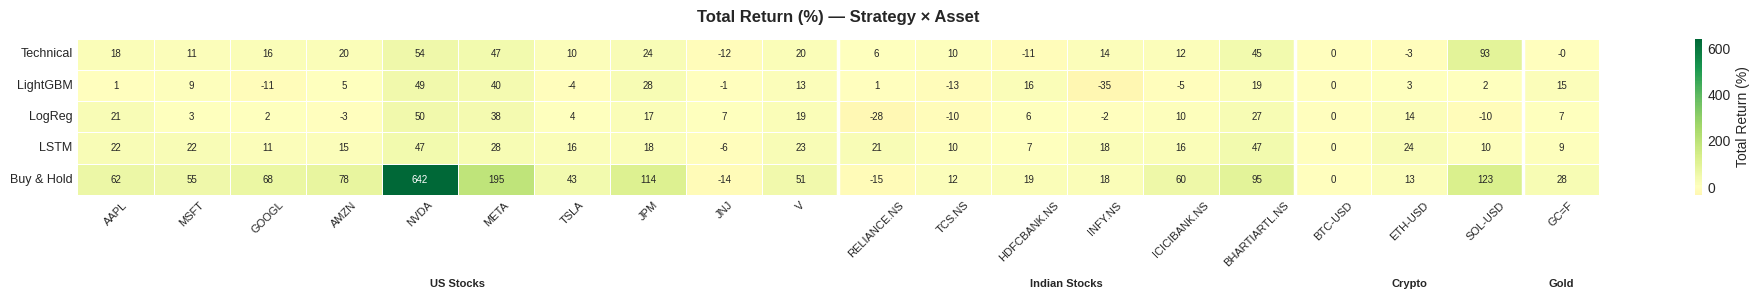

In [7]:
def plot_return_heatmap(comparison_df, save_dir):
    """
    Heatmap where rows = strategies, columns = assets, values = total return %.
    Assets are grouped by asset class for readability.
    """
    # build the pivot
    heatmap_data = comparison_df.pivot_table(
        index='strategy', columns='ticker', values='total_return'
    ) * 100

    # order columns by asset class grouping
    col_order = US_STOCKS + INDIAN_STOCKS + CRYPTO + GOLD
    col_order  = [t for t in col_order if t in heatmap_data.columns]
    heatmap_data = heatmap_data[col_order]

    # order rows
    row_order = [s for s in STRATEGIES if s in heatmap_data.index]
    heatmap_data = heatmap_data.loc[row_order]
    heatmap_data.index = [STRATEGY_LABELS.get(i, i) for i in heatmap_data.index]

    fig, ax = plt.subplots(figsize=(20, 4))
    sns.heatmap(
        heatmap_data,
        ax=ax,
        cmap='RdYlGn',   # red = negative, yellow = neutral, green = positive
        center=0,
        annot=True,
        fmt='.0f',
        annot_kws={'size': 7},
        linewidths=0.4,
        cbar_kws={'label': 'Total Return (%)'},
    )
    ax.set_title('Total Return (%) — Strategy × Asset', fontsize=12, fontweight='bold', pad=12)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', labelsize=8, rotation=45)
    ax.tick_params(axis='y', labelsize=9, rotation=0)

    # draw vertical lines to separate asset classes
    class_sizes = [len(US_STOCKS), len(INDIAN_STOCKS), len(CRYPTO), len(GOLD)]
    boundaries = np.cumsum(class_sizes[:-1])
    for b in boundaries:
        ax.axvline(b, color='white', linewidth=2.5)

    # add class labels above the heatmap
    class_labels = ['US Stocks', 'Indian Stocks', 'Crypto', 'Gold']
    starts = [0] + list(boundaries)
    for label, start, size in zip(class_labels, starts, class_sizes):
        ax.text(start + size / 2, -0.6, label, ha='center', va='bottom',
                fontsize=8, fontweight='bold', transform=ax.get_xaxis_transform())

    plt.tight_layout()
    path = os.path.join(save_dir, 'heatmaps', 'return_heatmap.png')
    plt.savefig(path, bbox_inches='tight', dpi=150)
    print(f'Saved: {path}')
    plt.show()


plot_return_heatmap(comparison_df, PLOTS_DIR)

## 7. Trade Markers (selected assets)

Saved: plots/comparison/trade_markers_AAPL.png


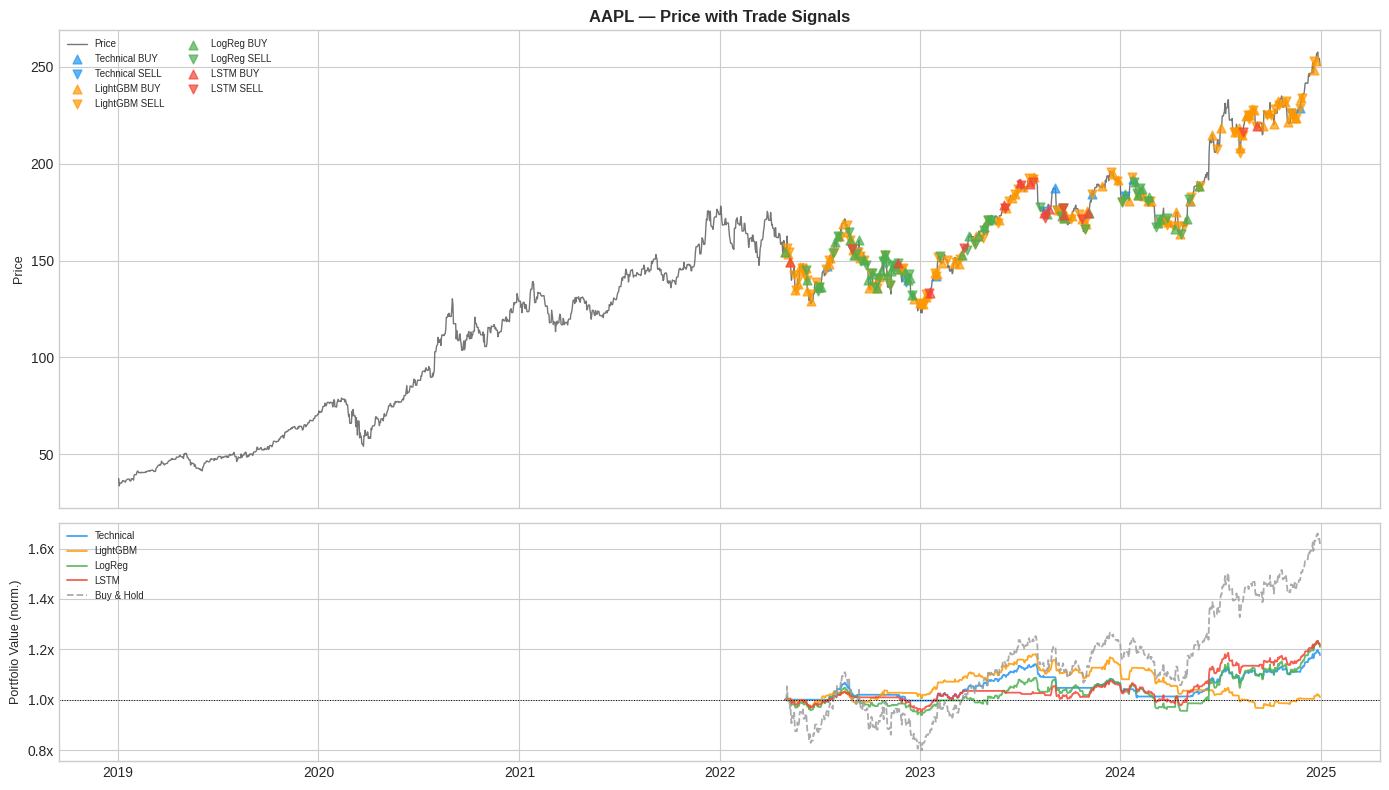

Saved: plots/comparison/trade_markers_RELIANCE.NS.png


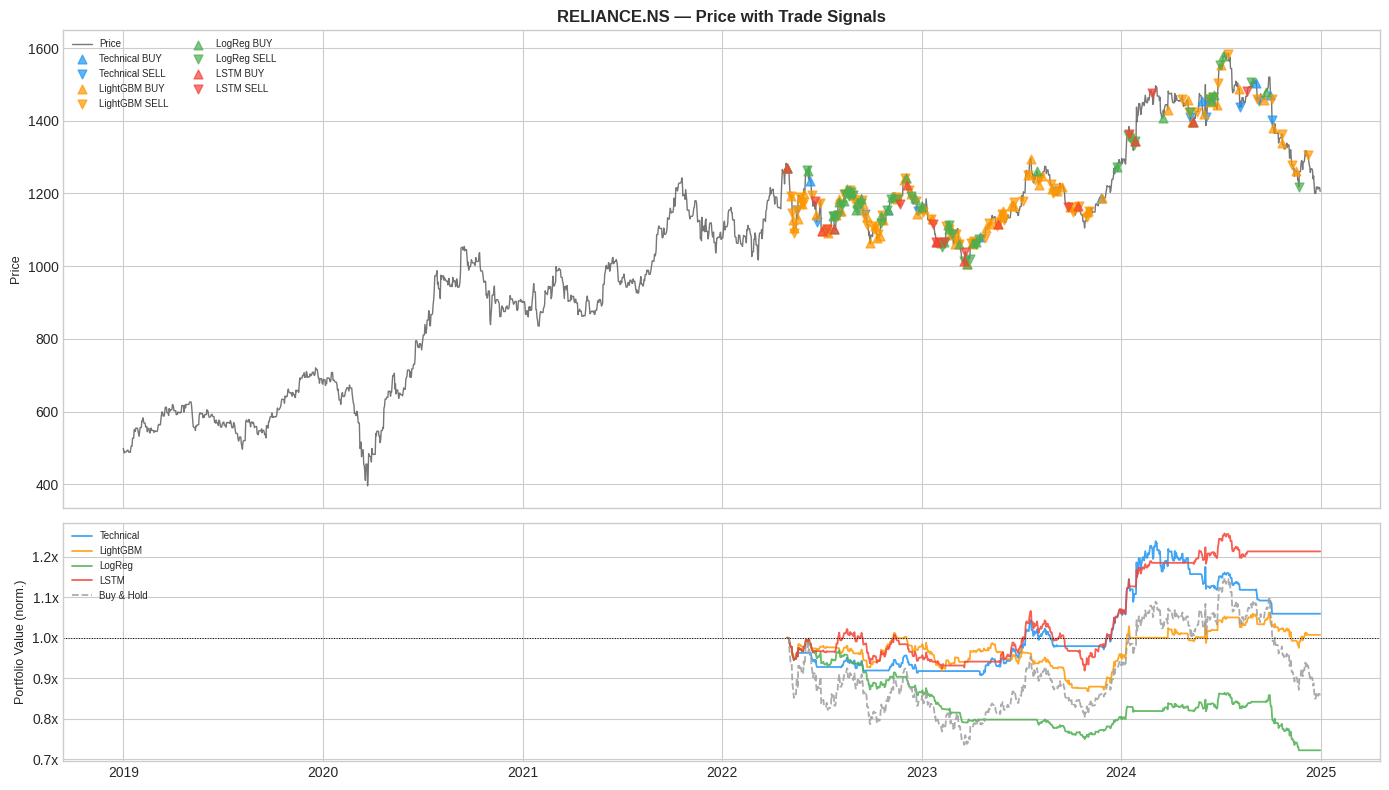

Saved: plots/comparison/trade_markers_BTC_USD.png


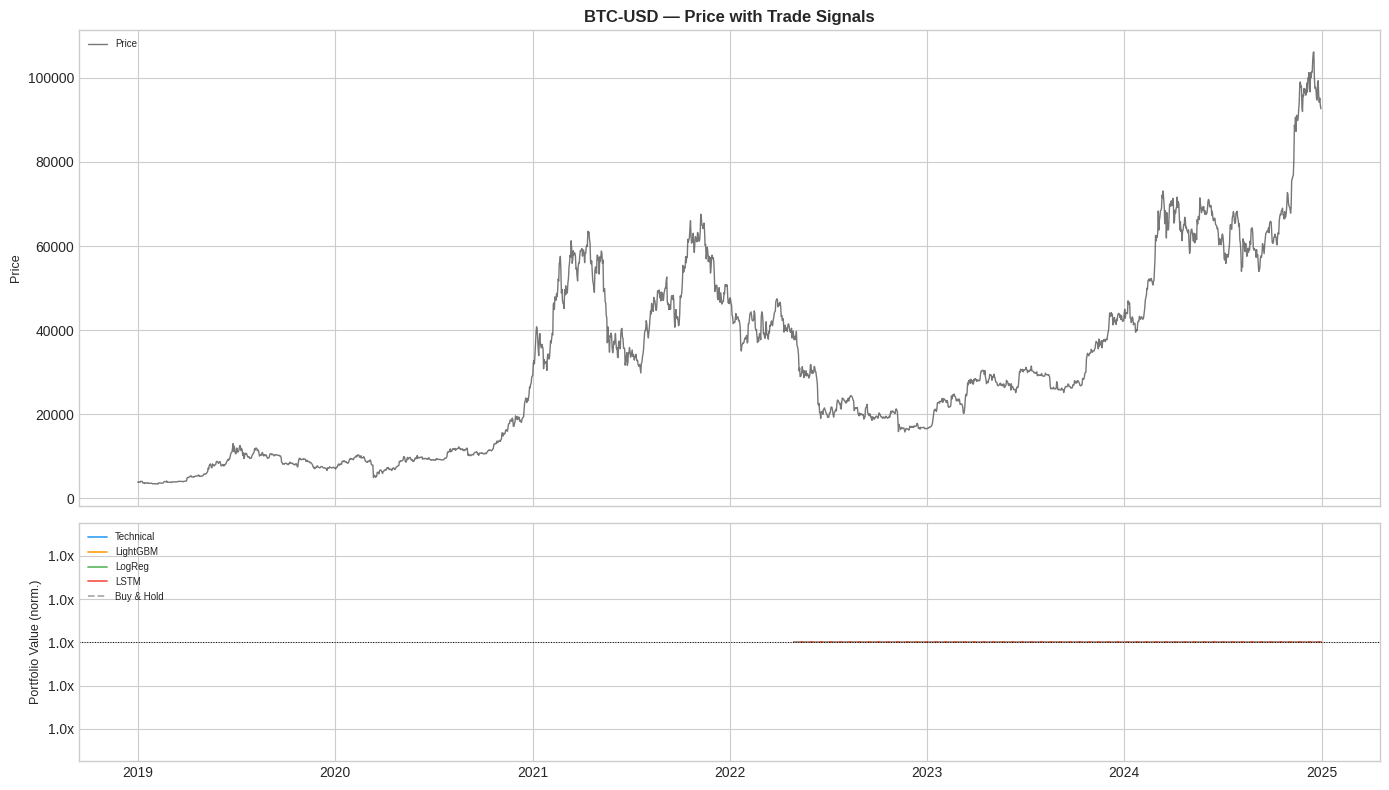

In [8]:
def plot_trade_markers(ticker, portfolios, orderbooks, save_dir):
    """
    Price chart with BUY/SELL markers overlaid for each strategy.
    Shows the portfolio value curve below the price.
    Saves one figure per ticker.
    """
    # load raw price data to get the Close series
    from config import FEATURES_DIR
    safe = ticker.replace('=', '_').replace('-', '_')
    features_path = os.path.join(FEATURES_DIR, f'{safe}_features.parquet')
    if not os.path.exists(features_path):
        print(f'Features file missing for {ticker}, skipping trade markers.')
        return

    price_df = pd.read_parquet(features_path)['Close']

    # only strategies that actually have order books
    strategies_with_orders = [s for s in STRATEGIES if s != 'buy_and_hold'
                               and s in orderbooks and len(orderbooks[s]) > 0]

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                             gridspec_kw={'height_ratios': [2, 1]})

    # top panel: price + trade markers
    axes[0].plot(price_df.index, price_df.values, color='#555555', linewidth=1.0,
                 alpha=0.8, label='Price', zorder=1)
    axes[0].set_ylabel('Price', fontsize=9)
    axes[0].set_title(f'{ticker} — Price with Trade Signals', fontweight='bold')

    for strategy in strategies_with_orders:
        ob = orderbooks[strategy]
        ticker_trades = ob[ob['ticker'] == ticker] if 'ticker' in ob.columns else ob

        if len(ticker_trades) == 0:
            continue

        buys  = ticker_trades[ticker_trades['signal'] == 'BUY']
        sells = ticker_trades[ticker_trades['signal'] == 'SELL']

        color = STRATEGY_COLORS.get(strategy, 'gray')
        label = STRATEGY_LABELS.get(strategy, strategy)

        # use price_local if present (INR for Indian stocks), else price
        price_col = 'price_local' if 'price_local' in ticker_trades.columns else 'price'

        if len(buys) > 0:
            axes[0].scatter(
                pd.to_datetime(buys['timestamp']),
                buys[price_col],
                marker='^', s=40, color=color, alpha=0.7, zorder=3,
                label=f'{label} BUY',
            )
        if len(sells) > 0:
            axes[0].scatter(
                pd.to_datetime(sells['timestamp']),
                sells[price_col],
                marker='v', s=40, color=color, alpha=0.7, zorder=3,
                label=f'{label} SELL',
            )

    axes[0].legend(fontsize=7, ncol=2, loc='upper left')

    # bottom panel: normalised portfolio value per strategy
    for strategy, ph in portfolios.items():
        subset = ph[ph['ticker'] == ticker]['portfolio_value']
        if len(subset) == 0:
            continue
        normalised = subset / subset.iloc[0]
        linestyle  = '--' if strategy == 'buy_and_hold' else '-'
        axes[1].plot(
            subset.index, normalised,
            label=STRATEGY_LABELS.get(strategy, strategy),
            color=STRATEGY_COLORS.get(strategy, 'gray'),
            linewidth=1.3, linestyle=linestyle, alpha=0.85,
        )

    axes[1].set_ylabel('Portfolio Value (norm.)', fontsize=9)
    axes[1].axhline(1.0, color='black', linewidth=0.7, linestyle=':')
    axes[1].legend(fontsize=7, loc='upper left')
    axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1fx'))

    plt.tight_layout()
    path = os.path.join(save_dir, 'comparison', f'trade_markers_{safe}.png')
    plt.savefig(path, bbox_inches='tight', dpi=150)
    print(f'Saved: {path}')
    plt.show()


# pick one from each asset class to keep it representative
for ticker in ['AAPL', 'RELIANCE.NS', 'BTC-USD']:
    plot_trade_markers(ticker, portfolios, orderbooks, PLOTS_DIR)

## 8. Drawdown (Underwater) Chart

Saved: plots/comparison/drawdown_underwater.png


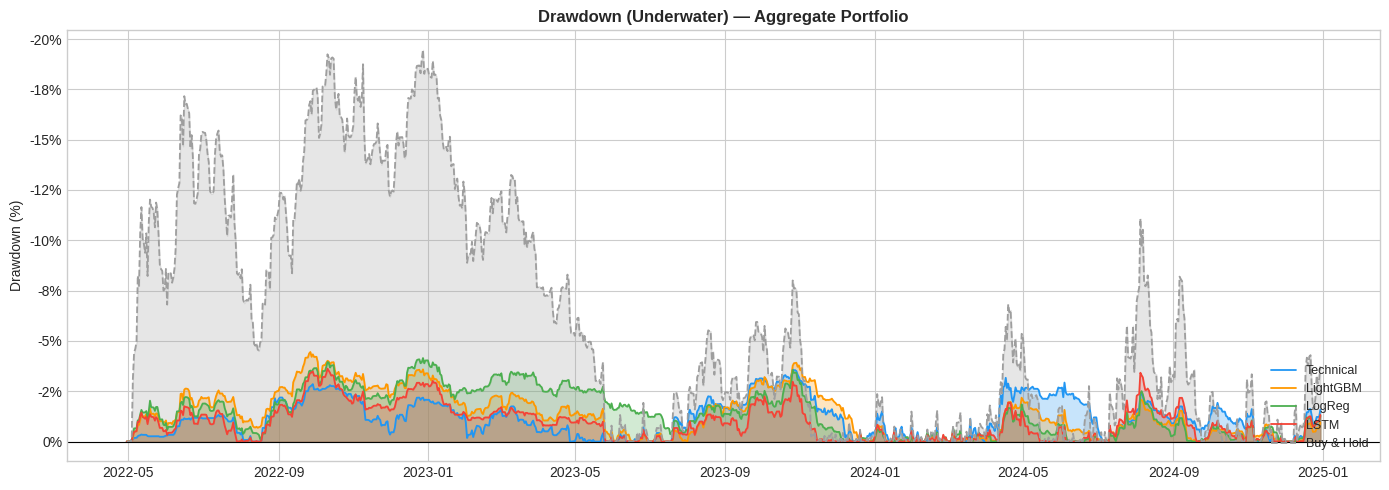

In [9]:
def plot_drawdown(portfolios, save_dir):
    """
    Aggregate portfolio value across all assets per strategy, then plot the
    drawdown (underwater) curve. Shows the worst ongoing loss from the peak.
    """
    fig, ax = plt.subplots(figsize=(14, 5))

    for strategy, ph in portfolios.items():
        # sum portfolio_value across all assets on each date
        agg = ph.groupby(ph.index)['portfolio_value'].sum()

        # drawdown from running peak
        rolling_peak = agg.cummax()
        drawdown = (agg - rolling_peak) / rolling_peak * 100  # as percentage

        ax.fill_between(
            drawdown.index, drawdown.values, 0,
            alpha=0.25, color=STRATEGY_COLORS.get(strategy, 'gray'),
        )
        ax.plot(
            drawdown.index, drawdown.values,
            label=STRATEGY_LABELS.get(strategy, strategy),
            color=STRATEGY_COLORS.get(strategy, 'gray'),
            linewidth=1.3,
            linestyle='--' if strategy == 'buy_and_hold' else '-',
        )

    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title('Drawdown (Underwater) — Aggregate Portfolio', fontweight='bold', fontsize=12)
    ax.set_ylabel('Drawdown (%)')
    ax.legend(fontsize=9, loc='lower right')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
    ax.invert_yaxis()   # drawdowns go downward visually

    plt.tight_layout()
    path = os.path.join(save_dir, 'comparison', 'drawdown_underwater.png')
    plt.savefig(path, bbox_inches='tight', dpi=150)
    print(f'Saved: {path}')
    plt.show()


plot_drawdown(portfolios, PLOTS_DIR)

## 9. Asset Class Breakdown

Saved: plots/comparison/asset_class_breakdown.png


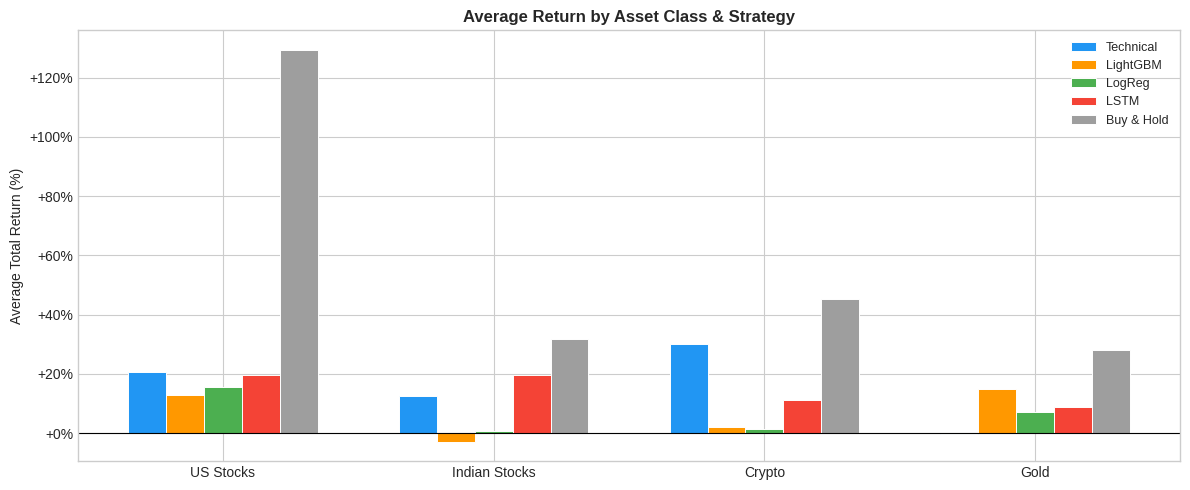

In [10]:
def plot_asset_class_breakdown(comparison_df, save_dir):
    """
    Average total return per strategy, broken down by asset class.
    Grouped bar chart: one group per asset class, bars = strategies.
    """
    asset_classes = ['us_stock', 'indian_stock', 'crypto', 'gold']
    class_labels  = ['US Stocks', 'Indian Stocks', 'Crypto', 'Gold']

    strategies = [s for s in STRATEGIES if s in comparison_df['strategy'].unique()]
    n_strategies = len(strategies)
    n_classes    = len(asset_classes)

    # avg return per (strategy, asset_class)
    grouped = comparison_df.groupby(['strategy', 'asset_class'])['total_return'].mean() * 100

    x      = np.arange(n_classes)
    bar_w  = 0.7 / n_strategies
    fig, ax = plt.subplots(figsize=(12, 5))

    for i, strategy in enumerate(strategies):
        returns = []
        for cls in asset_classes:
            val = grouped.get((strategy, cls), 0.0)
            returns.append(val if not np.isnan(val) else 0.0)

        offset = (i - n_strategies / 2 + 0.5) * bar_w
        bars = ax.bar(
            x + offset, returns, width=bar_w,
            label=STRATEGY_LABELS.get(strategy, strategy),
            color=STRATEGY_COLORS.get(strategy, 'gray'),
            edgecolor='white', linewidth=0.7,
        )

    ax.set_title('Average Return by Asset Class & Strategy', fontweight='bold', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(class_labels, fontsize=10)
    ax.set_ylabel('Average Total Return (%)')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.legend(fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%+.0f%%'))

    plt.tight_layout()
    path = os.path.join(save_dir, 'comparison', 'asset_class_breakdown.png')
    plt.savefig(path, bbox_inches='tight', dpi=150)
    print(f'Saved: {path}')
    plt.show()


plot_asset_class_breakdown(comparison_df, PLOTS_DIR)

## 10. Final Summary Report

In [11]:
def print_full_report(comparison_df):
    """Print a clean text summary of all strategies vs buy-and-hold."""

    strategies = [s for s in STRATEGIES if s in comparison_df['strategy'].unique()
                  and s != 'buy_and_hold']
    bh_data    = comparison_df[comparison_df['strategy'] == 'buy_and_hold']

    print('=' * 75)
    print('FINAL PERFORMANCE REPORT — All 20 Assets')
    print('=' * 75)

    for strategy in strategies:
        strat_data = comparison_df[comparison_df['strategy'] == strategy]
        label = STRATEGY_LABELS.get(strategy, strategy)

        avg_ret   = strat_data['total_return'].mean() * 100
        avg_sh    = strat_data['sharpe_ratio'].mean()
        avg_dd    = strat_data['max_drawdown'].mean() * 100
        total_tr  = strat_data['num_trades'].sum()

        bh_ret    = bh_data['total_return'].mean() * 100 if len(bh_data) > 0 else np.nan
        alpha     = avg_ret - bh_ret

        print(f'\n{label}')
        print(f'  Avg Return   : {avg_ret:>+7.1f}%')
        print(f'  Avg Sharpe   : {avg_sh:>+7.2f}')
        print(f'  Avg Max DD   : {avg_dd:>7.1f}%')
        print(f'  Total Trades : {total_tr:>7,}')
        print(f'  Alpha vs B&H : {alpha:>+7.1f}%')

    if len(bh_data) > 0:
        bh_ret = bh_data['total_return'].mean() * 100
        bh_sh  = bh_data['sharpe_ratio'].mean()
        bh_dd  = bh_data['max_drawdown'].mean() * 100
        print(f'\n{"Buy & Hold (baseline)"}')
        print(f'  Avg Return   : {bh_ret:>+7.1f}%')
        print(f'  Avg Sharpe   : {bh_sh:>+7.2f}')
        print(f'  Avg Max DD   : {bh_dd:>7.1f}%')

    print('\n' + '=' * 75)

    # best strategy per asset (by return)
    print('\nBest Strategy per Asset (by Total Return):')
    print('-' * 45)
    non_bh = comparison_df[comparison_df['strategy'] != 'buy_and_hold']
    for ticker in ALL_TICKERS:
        sub = non_bh[non_bh['ticker'] == ticker]
        if len(sub) == 0:
            continue
        best_row = sub.loc[sub['total_return'].idxmax()]
        label = STRATEGY_LABELS.get(best_row['strategy'], best_row['strategy'])
        print(f'  {ticker:<20}  {label:<12}  {best_row["total_return"]*100:>+6.1f}%')

    print('\nNotebook 4 complete. All plots saved to plots/')


print_full_report(comparison_df)

FINAL PERFORMANCE REPORT — All 20 Assets

Technical
  Avg Return   :   +18.6%
  Avg Sharpe   :   +0.42
  Avg Max DD   :    11.3%
  Total Trades :   8,931
  Alpha vs B&H :   -63.7%

LightGBM
  Avg Return   :    +6.7%
  Avg Sharpe   :   +0.20
  Avg Max DD   :    13.0%
  Total Trades :  13,207
  Alpha vs B&H :   -75.7%

LogReg
  Avg Return   :    +8.5%
  Avg Sharpe   :   +0.25
  Avg Max DD   :    11.6%
  Total Trades :  12,265
  Alpha vs B&H :   -73.8%

LSTM
  Avg Return   :   +17.8%
  Avg Sharpe   :   +0.55
  Avg Max DD   :     9.7%
  Total Trades :  12,593
  Alpha vs B&H :   -64.6%

Buy & Hold (baseline)
  Avg Return   :   +82.4%
  Avg Sharpe   :   +0.56
  Avg Max DD   :    31.0%


Best Strategy per Asset (by Total Return):
---------------------------------------------
  AAPL                  LSTM           +21.6%
  MSFT                  LSTM           +21.8%
  GOOGL                 Technical      +16.3%
  AMZN                  Technical      +20.3%
  NVDA                  Technical    